# Laboratório - Avaliação de Desempenho e Completude dos Métodos de

Busca

## Ajustando ambiente

In [1]:
import random
import time
import math
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

## Motivação

Os capítulos 1 e 2 ensinaram BFS, busca de custo uniforme (UCS), busca
gulosa (GBFS) e A\* sobre um grafo didático pequeno (13 cidades, a
maioria com arestas de custo igual). Esse grafo é ótimo para acompanhar
o algoritmo passo a passo, mas pequeno demais para revelar diferenças
reais de desempenho entre as estratégias, e uniforme demais para mostrar
que **nem todo algoritmo encontra o caminho de menor custo**. Este
capítulo gera um grafo aleatório maior — com pesos de aresta variados e
derivados de coordenadas reais — e usa as implementações prontas e
testadas do [NetworkX](https://networkx.org/) para resolver dezenas de
pares (estado inicial, objetivo), medindo tempo de execução, custo e
completude de cada estratégia.

## Objetivos de Aprendizagem

- **Gerar um grafo aleatório adequado para busca:** um grafo geométrico
  conexo, com pesos de aresta que tornam a heurística de distância em
  linha reta admissível por construção.
- **Reaproveitar buscas prontas do NetworkX:** usar as implementações
  nativas de busca em largura, Dijkstra (equivalente a UCS) e A\*, em
  vez de reimplementar os algoritmos.
- **Obter a Busca Gulosa a partir do A\*:** entender por que anular o
  custo acumulado no A\* do NetworkX produz exatamente o comportamento
  da GBFS.
- **Medir desempenho:** comparar tempo de execução, custo e comprimento
  do caminho encontrado por cada algoritmo em múltiplos cenários.
- **Avaliar completude:** verificar se cada algoritmo relata
  corretamente a ausência de solução quando ela não existe.

## Implementação

### Geração do grafo aleatório

Cada nó recebe uma posição aleatória num plano 2D; dois nós são
conectados se a distância entre eles for menor que um raio (grafo
geométrico aleatório). O peso de cada aresta é a própria distância
euclidiana entre os pontos — é isso que garante que a distância em linha
reta até o objetivo nunca superestima o custo real do caminho
(desigualdade triangular), tornando-a uma heurística admissível para
qualquer par (estado, objetivo), sem precisar de um dicionário de
heurística fixo como no capítulo 2.

In [2]:
def generate_random_graph(n_nodes=40, seed=42):
    """Gera um grafo geométrico aleatório conexo, com nós posicionados em um plano 2D."""
    radius = 0.2
    graph = None
    for _ in range(20):
        graph = nx.random_geometric_graph(n_nodes, radius, seed=seed)
        if nx.is_connected(graph):
            break
        radius += 0.05
    else:
        raise RuntimeError('Não foi possível gerar um grafo conexo; ajuste n_nodes ou o raio inicial.')

    coords = nx.get_node_attributes(graph, 'pos')
    for a, b in graph.edges:
        graph[a][b]['weight'] = math.dist(coords[a], coords[b])

    return graph, coords

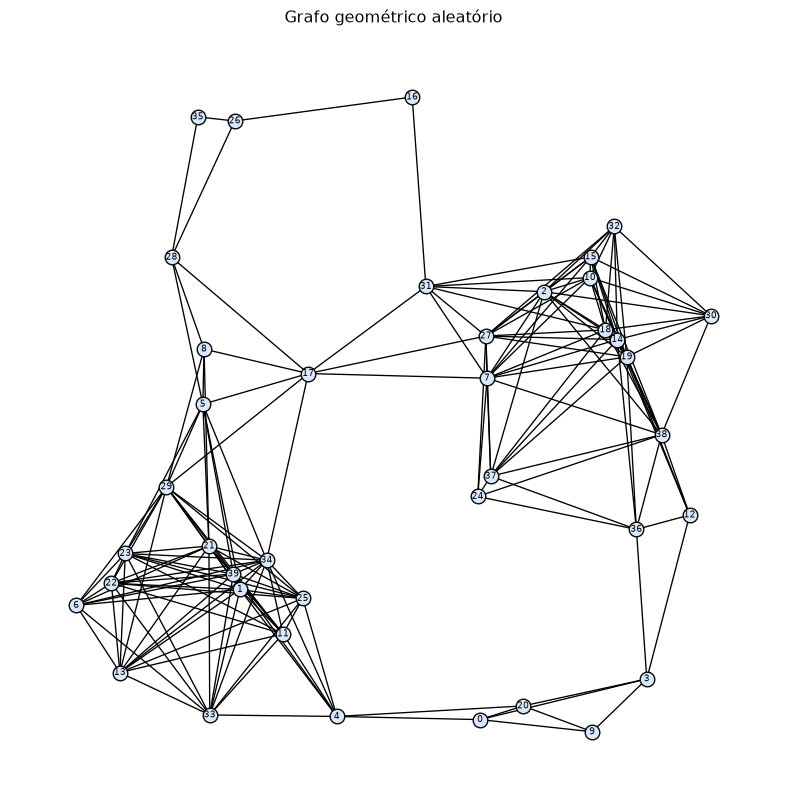

In [3]:
graph, coords = generate_random_graph()

plt.figure(figsize=(8, 8))
nx.draw(graph, pos=coords, node_size=120, node_color='#d9e8fb', edgecolors='black', with_labels=True, font_size=7)
plt.title('Grafo geométrico aleatório')
plt.show()

### Funções de busca

BFS, UCS (Dijkstra) e A\* já têm implementação pronta no NetworkX —
reaproveitamos essas funções em vez de reescrevê-las. A Busca Gulosa não
tem uma função própria: obtemos o mesmo comportamento a partir do A\*,
anulando o peso das arestas (`weight=0`) para que a ordenação da
fronteira dependa só da heurística $h(n)$, exatamente como a GBFS do
capítulo 2.

In [4]:
def bfs_path(graph, start, goal):
    """Busca em largura: caminho com o menor número de arestas, via NetworkX."""
    try:
        return nx.shortest_path(graph, start, goal, weight=None)
    except nx.NetworkXNoPath:
        return None

def dfs_path(graph, start, goal):
    """Um caminho encontrado por busca em profundidade, via NetworkX (não é garantidamente o mais curto)."""
    tree = nx.dfs_tree(graph, start)
    if goal not in tree:
        return None
    return nx.shortest_path(tree, start, goal)

def ucs_path(graph, start, goal):
    """Busca de custo uniforme: caminho de menor custo, via Dijkstra do NetworkX."""
    try:
        return nx.dijkstra_path(graph, start, goal, weight='weight')
    except nx.NetworkXNoPath:
        return None

def astar_path_search(graph, start, goal, coords):
    """Busca A*: caminho de menor custo total estimado, via NetworkX."""
    heuristic = lambda a, b: math.dist(coords[a], coords[b])
    try:
        return nx.astar_path(graph, start, goal, heuristic=heuristic, weight='weight')
    except nx.NetworkXNoPath:
        return None

def gbfs_path(graph, start, goal, coords):
    """Busca gulosa: A* do NetworkX com o custo acumulado g(n) anulado, restando só h(n)."""
    heuristic = lambda a, b: math.dist(coords[a], coords[b])
    try:
        return nx.astar_path(graph, start, goal, heuristic=heuristic, weight=lambda u, v, d: 0)
    except nx.NetworkXNoPath:
        return None

def path_cost(graph, path):
    """Soma o peso das arestas de um caminho encontrado no grafo."""
    if not path:
        return None
    return nx.path_weight(graph, path, weight='weight')

#### Complexidade assintótica

Como aqui a busca roda sobre um **grafo** (via NetworkX), a notação
natural é em função de $V$ (número de nós) e $E$ (número de arestas) —
diferente da notação $b$ (fator de ramificação) e $d$ (profundidade)
usada nos capítulos 1 e 2 para busca em árvore. As duas descrevem a
mesma ideia sob premissas diferentes; a tabela abaixo usa a notação de
grafo, que é a que se aplica ao código deste capítulo.

| Algoritmo      | Tempo (pior caso)   | Espaço |
|----------------|---------------------|--------|
| BFS            | $O(V + E)$          | $O(V)$ |
| DFS            | $O(V + E)$          | $O(V)$ |
| UCS (Dijkstra) | $O((V + E) \log V)$ | $O(V)$ |
| A\*            | $O((V + E) \log V)$ | $O(V)$ |
| GBFS           | $O((V + E) \log V)$ | $O(V)$ |

BFS e DFS visitam cada nó e cada aresta no máximo uma vez, daí $O(V+E)$.
UCS, A\* e GBFS usam uma fila de prioridade (heap binário, a
implementação do NetworkX) para decidir o próximo nó a expandir, o que
custa $O(\log V)$ por operação — daí o fator extra. GBFS tem exatamente
a mesma forma do A\* (é literalmente a mesma função, com o peso zerado):
trocar o critério de ordenação não muda a classe de complexidade no pior
caso, só o comportamento típico.

## Exemplo prático

In [5]:
start_node, goal_node = 0, len(graph) - 1

algorithms = {
    'BFS': lambda: bfs_path(graph, start_node, goal_node),
    'DFS': lambda: dfs_path(graph, start_node, goal_node),
    'UCS': lambda: ucs_path(graph, start_node, goal_node),
    'GBFS': lambda: gbfs_path(graph, start_node, goal_node, coords),
    'A*': lambda: astar_path_search(graph, start_node, goal_node, coords),
}

for name, search in algorithms.items():
    start_time = time.perf_counter()
    path = search()
    elapsed = time.perf_counter() - start_time
    print(f"{name:5} | encontrou={path is not None!s:5} | custo={path_cost(graph, path)} | "
          f"arestas={len(path) - 1 if path else None} | tempo={elapsed * 1000:.3f} ms")

BFS   | encontrou=True  | custo=0.4852840934736458 | arestas=2 | tempo=0.330 ms
DFS   | encontrou=True  | custo=3.6196780590759605 | arestas=19 | tempo=0.598 ms
UCS   | encontrou=True  | custo=0.4852840934736458 | arestas=2 | tempo=0.466 ms
GBFS  | encontrou=True  | custo=0.4852840934736458 | arestas=2 | tempo=0.198 ms
A*    | encontrou=True  | custo=0.4852840934736458 | arestas=2 | tempo=0.021 ms

## Avaliação de desempenho

Sorteamos vários pares (estado inicial, objetivo) diferentes e rodamos
os cinco algoritmos em cada um, registrando tempo, custo e comprimento
do caminho encontrado.

In [6]:
random.seed(42)
NUM_TRIALS = 20

nodes = list(graph.nodes)
test_pairs = [tuple(random.sample(nodes, 2)) for _ in range(NUM_TRIALS)]

results = []
for start, goal in test_pairs:
    for name, search in {
        'BFS': lambda: bfs_path(graph, start, goal),
        'DFS': lambda: dfs_path(graph, start, goal),
        'UCS': lambda: ucs_path(graph, start, goal),
        'GBFS': lambda: gbfs_path(graph, start, goal, coords),
        'A*': lambda: astar_path_search(graph, start, goal, coords),
    }.items():
        start_time = time.perf_counter()
        path = search()
        elapsed = time.perf_counter() - start_time
        results.append({
            'algoritmo': name,
            'encontrou': path is not None,
            'custo': path_cost(graph, path),
            'arestas': len(path) - 1 if path else None,
            'tempo_ms': elapsed * 1000,
        })

In [7]:
results_df = pd.DataFrame(results)
summary = results_df.groupby('algoritmo').agg(
    taxa_sucesso=('encontrou', 'mean'),
    custo_medio=('custo', 'mean'),
    arestas_media=('arestas', 'mean'),
    tempo_medio_ms=('tempo_ms', 'mean'),
).round(3)

display(summary)

Como o grafo gerado é conexo, `taxa_sucesso` deve ficar em `1.0` para os
cinco algoritmos — todos encontram *algum* caminho em todo par testado.
É nas outras colunas que as diferenças aparecem: `custo_medio` deve ser
o mesmo (e o mais baixo) para UCS e A*, já que ambos garantem o caminho
de menor custo; BFS e GBFS tendem a um `custo_medio` mais alto, porque
otimizam outra coisa (menor número de arestas e heurística,
respectivamente), não o custo acumulado. `arestas_media` costuma ser
menor para a BFS, que por definição encontra o caminho com menos passos,
mesmo que mais caro. Em `tempo_medio_ms`, espere a DFS ser a mais rápida
(explora sem se preocupar em comparar alternativas) e o A* ser
competitivo com a UCS ou mais rápido — a heurística evita expandir ramos
que se afastam do objetivo, mesmo mantendo a garantia de custo mínimo.

Vale conectar isso com a complexidade assintótica da seção anterior: BFS
e DFS são $O(V+E)$, enquanto UCS, A\* e GBFS são $O((V+E)\log V)$ por
causa da fila de prioridade — por isso não é surpresa se
`tempo_medio_ms` for um pouco maior para os três, mesmo num grafo
pequeno como este. O ponto mais interessante é que A\* e UCS têm a
**mesma** complexidade de pior caso, mas na prática A\* tende a ser mais
rápido: a heurística poda ramos que se afastam do objetivo, então A\*
efetivamente processa uma fração de $V$, enquanto UCS, sem heurística
nenhuma, se aproxima mais do pior caso teórico. O limite assintótico é o
mesmo; o comportamento típico não.

## Avaliação de completude

Completude não é uma propriedade “tudo ou nada” de um algoritmo
isoladamente — ela depende de como o espaço de busca está estruturado.
Esta seção testa os cinco algoritmos contra um caso-base (objetivo
inalcançável num grafo bem-comportado) e quatro “armadilhas” estruturais
clássicas que a literatura usa para separar algoritmos completos de
incompletos: ciclos sem controle de visitados, ramos muito profundos,
fator de ramificação infinito e custos de aresta nulos ou negativos.

### Cenário A — objetivo inalcançável

Adicionamos um nó propositalmente isolado (sem nenhuma aresta) e
tentamos alcançá-lo a partir de um estado conectado. Um algoritmo
completo deve relatar corretamente que não há solução, em vez de travar
ou lançar um erro inesperado.

In [8]:
graph_with_isolated_node = graph.copy()
graph_with_isolated_node.add_node('isolated')
coords_with_isolated_node = dict(coords)

for name, search in {
    'BFS': lambda: bfs_path(graph_with_isolated_node, 0, 'isolated'),
    'DFS': lambda: dfs_path(graph_with_isolated_node, 0, 'isolated'),
    'UCS': lambda: ucs_path(graph_with_isolated_node, 0, 'isolated'),
    'GBFS': lambda: gbfs_path(graph_with_isolated_node, 0, 'isolated', coords_with_isolated_node) if 'isolated' in coords_with_isolated_node else 'N/A (sem coordenada)',
    'A*': lambda: astar_path_search(graph_with_isolated_node, 0, 'isolated', coords_with_isolated_node) if 'isolated' in coords_with_isolated_node else 'N/A (sem coordenada)',
}.items():
    print(name, '->', search())

BFS -> None
DFS -> None
UCS -> None
GBFS -> N/A (sem coordenada)
A* -> N/A (sem coordenada)

Espera-se que as cinco linhas impressas terminem em `None` (ou
equivalente): nenhum algoritmo encontra caminho até `'isolated'`, porque
não existe nenhuma aresta ligando esse nó ao resto do grafo. O ponto do
teste não é o valor em si — é que nenhum algoritmo trava, entra em loop
infinito ou lança um erro inesperado ao lidar com um objetivo
inalcançável; cada um percorre todo o espaço de busca acessível a partir
do estado inicial e conclui corretamente que não há solução.

### Cenário B — Ciclos sem controle de estados visitados

O resultado acima só vale porque `dfs_path` evita repetir estados (é o
que `nx.dfs_tree` garante internamente) — isso a torna completa em
qualquer grafo finito. Uma DFS “ingênua”, sem esse controle, não tem
essa garantia: num grafo com ciclos, ela pode ficar alternando entre os
mesmos poucos nós indefinidamente, sem nunca esgotar as alternativas e
sem nunca concluir que não há solução. Como não dá para deixar uma
célula rodando para sempre, colocamos um limite de passos de segurança —
se ele for atingido, é sinal de que a busca não terminaria sozinha. (O
mesmo raciocínio vale para BFS, UCS e A\*: qualquer um deles, sem
controle de visitados, cairia na mesma armadilha num grafo cíclico.
`nx.shortest_path`, `nx.dijkstra_path` e `nx.astar_path` já fazem esse
controle internamente, por isso não repetimos a demonstração para cada
um.)

In [9]:
def naive_dfs_path(graph, start, goal, max_steps=2000):
    """DFS sem controle de estados visitados: pode ciclar indefinidamente em grafos com ciclos."""
    frontier = [[start]]
    steps = 0

    while frontier:
        steps += 1
        if steps > max_steps:
            return f'não terminou em {max_steps} passos'

        path = frontier.pop()
        current = path[-1]

        if current == goal:
            return path

        for neighbor in graph.neighbors(current):
            frontier.append(path + [neighbor])

    return None

In [10]:
print('DFS (com controle de visitados):   ', dfs_path(graph_with_isolated_node, 0, 'isolated'))
print('DFS ingênua (sem controle de visitados):', naive_dfs_path(graph_with_isolated_node, 0, 'isolated'))

DFS (com controle de visitados):    None
DFS ingênua (sem controle de visitados): não terminou em 2000 passos

O esperado é uma diferença nítida entre as duas linhas: `dfs_path`
retorna `None` quase instantaneamente, porque esgota o componente
alcançável e conclui corretamente que `'isolated'` não está nele. Já
`naive_dfs_path`, na maioria dos grafos gerados (que costumam ter mais
arestas do que uma árvore, logo têm ciclos), deve atingir `max_steps`
sem terminar — sem controle de visitados, ela fica reexplorando
repetidamente as mesmas arestas dentro de um ciclo, nunca “esgotando” as
alternativas. É exatamente essa a incompletude teórica da DFS em árvore
que o capítulo 1 menciona. (Se o grafo gerado nesta execução for uma
árvore, sem ciclos, `naive_dfs_path` também terminaria corretamente —
nesse caso, aumente `n_nodes` ou o raio em `generate_random_graph` para
garantir arestas extras além da árvore geradora.)

### Cenário C — Ramos muito profundos

Controlar visitados resolve o problema dos ciclos, mas não resolve um
segundo problema, mais fundamental: mesmo sem repetir nenhum estado, a
DFS pode se comprometer com um ramo muito profundo (ou, no limite
teórico, infinito) e nunca voltar para tentar um ramo raso onde o
objetivo estaria a um passo de distância. Isso não depende de ciclo
nenhum — depende só da ordem de exploração (profundidade primeiro).

Construímos um grafo em forma de “Y”: um objetivo (`'shallow_goal'`) a
um único passo do início, e uma cadeia longa (sem o objetivo) partindo
do mesmo nó. Adicionamos a aresta do objetivo raso *antes* da cadeia
longa, para que a DFS (que empilha e desempilha pelo final da lista)
escolha mergulhar na cadeia longa primeiro — exatamente o comportamento
que uma DFS real teria ao encontrar esse ramo primeiro.

In [11]:
def capped_dfs_path(graph, start, goal, max_steps=2000):
    """DFS com controle de visitados, mas com limite de passos — simula um ramo profundo demais para terminar em tempo hábil."""
    frontier = [[start]]
    visited = set()
    steps = 0

    while frontier:
        steps += 1
        if steps > max_steps:
            return f'não terminou em {max_steps} passos'

        path = frontier.pop()
        current = path[-1]

        if current == goal:
            return path
        if current in visited:
            continue
        visited.add(current)

        for neighbor in graph.neighbors(current):
            if neighbor not in visited:
                frontier.append(path + [neighbor])

    return None


DEEP_CHAIN_LENGTH = 5000

deep_branch_graph = nx.Graph()
deep_branch_graph.add_edge(0, 'shallow_goal')
nx.add_path(deep_branch_graph, range(DEEP_CHAIN_LENGTH))

In [12]:
print('DFS com limite de passos:', capped_dfs_path(deep_branch_graph, 0, 'shallow_goal', max_steps=50))
print('BFS:                     ', bfs_path(deep_branch_graph, 0, 'shallow_goal'))

DFS com limite de passos: não terminou em 50 passos
BFS:                      [0, 'shallow_goal']

O objetivo está a **um** passo do início, mas a DFS com `max_steps=50`
deve retornar “não terminou”: ela mergulha pela cadeia longa (nós
`0, 1, 2, 3, ...`) e só voltaria para tentar `'shallow_goal'` depois de
esgotar toda a cadeia — o que, com uma cadeia de 5.000 nós e um limite
de 50 passos, nunca acontece dentro do orçamento. A BFS, por explorar em
camadas, encontra `'shallow_goal'` na primeira camada, independentemente
de quão longa seja a cadeia ignorada. Isso ilustra por que a completude
da DFS depende do tamanho/profundidade do espaço de busca, mesmo com
controle de visitados — enquanto a completude da BFS (com fator de
ramificação finito) não depende disso.

Vale uma nota sobre notação: a distinção clássica “DFS gasta
$O(b \cdot d)$ de memória, BFS gasta $O(b^d)$” (capítulos 1/2, $b$ =
fator de ramificação, $d$ = profundidade) é sobre busca em **árvore**,
sem grafo finito e sem conjunto de visitados — é o cenário em que a
economia de memória da DFS realmente compensa. Nas nossas funções, que
rodam sobre um grafo finito com controle de visitados, ambas são $O(V)$
de espaço no pior caso (tabela na seção “Funções de busca”) — a vantagem
de memória da DFS desaparece nesse contexto. O que sobra, como este
cenário mostra, é só a fragilidade de tempo: comprometer-se com o ramo
errado primeiro.

### Cenário D — Fator de ramificação infinito

Nem toda estrutura cabe num `networkx.Graph` (que exige uma lista finita
de vizinhos por nó) — um nó com infinitos filhos só pode ser
representado por uma função geradora. Simulamos isso com um gerador que
nunca para de produzir “filhos” para um nó específico, e uma BFS escrita
à mão que consome essa função em vez de um grafo do NetworkX.

In [13]:
def infinite_children(node):
    """Gerador de filhos 'infinitos' para simular um nó com fator de ramificação infinito."""
    i = 0
    while True:
        yield f'{node}_child_{i}'
        i += 1

def bfs_with_generator(root, goal, get_children, max_expansions=2000):
    """BFS sobre uma função geradora de filhos (não um grafo do NetworkX), para simular ramificação infinita."""
    frontier = [root]
    expansions = 0

    while frontier:
        current = frontier.pop(0)
        if current == goal:
            return current

        for child in get_children(current):
            expansions += 1
            if expansions > max_expansions:
                return f'não terminou em {max_expansions} expansões (ainda na 1ª camada)'
            frontier.append(child)

    return None


def root_children(node):
    return infinite_children(node) if node == 'root' else []

In [14]:
print('BFS com nó de ramificação infinita:', bfs_with_generator('root', 'goal_no_nivel_2', root_children, max_expansions=2000))

BFS com nó de ramificação infinita: não terminou em 2000 expansões (ainda na 1ª camada)

O objetivo (`'goal_no_nivel_2'`) nem existe de fato neste grafo — o
ponto é que a BFS jamais chegaria a verificar isso: como `'root'` tem
infinitos filhos, o laço que enumera os vizinhos de `'root'` nunca
termina naturalmente, e a BFS fica presa expandindo a primeira camada
para sempre. Diferente do Cenário C, aqui é a própria **BFS** que falha
— o fator de ramificação infinito ataca justamente a estratégia
“explorar uma camada inteira antes de avançar”, que era a vantagem da
BFS nos cenários anteriores.

### Cenário E — Custos de aresta nulos ou negativos

O UCS/Dijkstra garante o caminho de menor custo sob a premissa de que
nenhuma aresta tem peso negativo.

Arestas de custo **zero** não quebram essa premissa. Uma implementação
correta, como a nossa, marca um estado como resolvido assim que ele é
retirado da fronteira e não o reconsidera depois — um ciclo de custo
zero não faz o algoritmo repetir esse estado.

O problema real aparece com pesos **negativos**. Um ciclo cujo custo
total é negativo torna o próprio conceito de “caminho mais barato” mal
definido: percorrer o ciclo mais vezes sempre reduz o custo, então o
mínimo verdadeiro seria $-\infty$.

In [15]:
negative_cycle_graph = nx.DiGraph()
negative_cycle_graph.add_weighted_edges_from([
    ('A', 'B', 1),
    ('B', 'C', -3),
    ('C', 'A', 1),
    ('A', 'goal', 10),
])

print('Existe ciclo de custo negativo alcançável a partir de A?', nx.negative_edge_cycle(negative_cycle_graph, weight='weight'))

try:
    print('UCS (Dijkstra):', ucs_path(negative_cycle_graph, 'A', 'goal'))
except ValueError as erro:
    print('UCS (Dijkstra) se recusa a responder:', erro)

try:
    print('Bellman-Ford:', nx.bellman_ford_path(negative_cycle_graph, 'A', 'goal', weight='weight'))
except nx.NetworkXUnbounded as erro:
    print('Bellman-Ford se recusa a responder:', erro)

Existe ciclo de custo negativo alcançável a partir de A? True
UCS (Dijkstra) se recusa a responder: ('Contradictory paths found:', 'negative weights?')
Bellman-Ford se recusa a responder: Negative cycle detected.

Perceba que o `nx.negative_edge_cycle` confirma que há um ciclo de custo
negativo alcançável a partir de `'A'`.

Rastreando o Dijkstra à mão: ele finaliza `A` com distância 0, depois
`B` (1), depois `C` (1 + (-3) = -2). Ao expandir `C`, encontra `A` de
novo com distância `-2 + 1 = -1` — **menor que a distância já finalizada
para `A`**. O NetworkX percebe essa inconsistência e levanta
`ValueError` em vez de devolver um caminho errado silenciosamente — só
que sem dizer *por quê* (a mensagem é genérica: “contradictory paths
found”). O Bellman-Ford vai além: identifica explicitamente a causa (o
ciclo negativo) e se recusa a responder de forma direcionada
(`NetworkXUnbounded`).

Nos dois casos o algoritmo não trava nem retorna um resultado incorreto
silenciosamente — mas nenhum dos dois calcula “o caminho mais barato”,
porque essa noção deixa de fazer sentido na presença de um ciclo de
custo negativo. A\* e a GBFS herdam a mesma dependência de custos não
negativos, já que também usam `weight` para calcular $g(n)$.

### A heurística do A\* e da GBFS: completude vs. otimalidade

Vale corrigir uma confusão comum: uma heurística inadmissível (que
superestima o custo restante) **não tira a completude** do A\* num grafo
finito com pesos não negativos — ele ainda vai, no pior caso, considerar
todos os nós alcançáveis. O que a inadmissibilidade compromete é a
**otimalidade**: o A\* pode devolver um caminho mais caro do que o
necessário, e a GBFS (que ignora completamente $g(n)$) é ainda mais
vulnerável a isso, podendo ser desviada para um caminho bem pior.

In [16]:
misleading_graph = nx.DiGraph()
misleading_graph.add_weighted_edges_from([
    ('A', 'B', 1), ('B', 'C', 1), ('C', 'goal', 1),  # caminho real mais barato: custo 3
    ('A', 'D', 10), ('D', 'goal', 1),                 # caminho mais caro: custo 11
])
misleading_heuristic = {'A': 0, 'B': 8, 'C': 1, 'D': 1, 'goal': 0}  # h(B)=8 superestima muito o custo restante (real: 2)

greedy_result = nx.astar_path(misleading_graph, 'A', 'goal', heuristic=lambda a, b: misleading_heuristic[a], weight=lambda u, v, d: 0)
astar_result = nx.astar_path(misleading_graph, 'A', 'goal', heuristic=lambda a, b: misleading_heuristic[a], weight='weight')

print('GBFS (só heurística):', greedy_result, '- custo real:', path_cost(misleading_graph, greedy_result))
print('A* (custo + heurística):', astar_result, '- custo real:', path_cost(misleading_graph, astar_result))

GBFS (só heurística): ['A', 'D', 'goal'] - custo real: 11
A* (custo + heurística): ['A', 'B', 'C', 'goal'] - custo real: 3

Com essa heurística propositalmente enganosa, a GBFS deve escolher
`A -> D -> goal` (custo real 11): como só olha $h(n)$, e $h(D)=1$ parece
mais promissor que $h(B)=8$, ela nunca chega a considerar o caminho por
B.

Por outro lado, o A\*, por somar $g(n)+h(n)$, ainda prefere `B` no
primeiro passo ($f(B)=1+8=9$ contra $f(D)=10+1=11$) e termina
encontrando o caminho ótimo `A -> B -> C -> goal` (custo 3) — mesmo
recebendo exatamente a mesma heurística ruim. Isso mostra, lado a lado,
por que a GBFS é mais frágil a heurísticas de má qualidade do que o A*:
o custo acumulado que o A* carrega funciona como um contrapeso que a
GBFS não tem.

## Perguntas para reflexão

1.  A tabela de desempenho mostra que UCS e A\* sempre encontram o
    caminho de menor custo, mas com tempos e comprimentos de caminho
    diferentes dos demais algoritmos. O que isso revela sobre o papel de
    uma heurística admissível: ela muda *o que* é encontrado, ou só
    *quão rápido* se chega lá?
2.  BFS e GBFS raramente coincidem com o caminho de custo mínimo
    encontrado por UCS/A\*. Em que tipo de aplicação essa perda de
    otimalidade seria aceitável em troca de velocidade ou simplicidade,
    e em que tipo ela seria inaceitável?
3.  Todos os algoritmos reportaram corretamente a ausência de caminho
    até o nó isolado. Isso significa que, na prática, qualquer um deles
    poderia substituir os outros? O que a completude garante sobre um
    algoritmo de busca — e o que ela deixa completamente em aberto sobre
    a qualidade da solução encontrada?
4.  Se este grafo fosse muito maior (milhões de nós, como uma malha
    viária real), qual desses algoritmos você escolheria para uma
    aplicação que precisa de resposta em tempo real, e qual para uma que
    exige a rota mais barata garantida? Justifique com base no que os
    resultados deste capítulo mostraram sobre cada um.

## Key takeaways

- Nem todo algoritmo de busca é ótimo em custo: BFS garante o menor
  número de arestas, não o menor custo — só UCS e A\* garantem isso num
  grafo com pesos variados.
- A Busca Gulosa não precisa de uma implementação própria: é o A\* com o
  custo acumulado `g(n)` anulado, restando só a heurística.
- Reaproveitar implementações testadas (NetworkX) permite focar a
  avaliação no comportamento dos algoritmos, não na correção do próprio
  código.
- Completude (sempre reportar corretamente quando não há solução) é uma
  propriedade distinta de otimalidade (encontrar o melhor caminho) — os
  testes deste capítulo avaliam coisas diferentes.
- A completude não é uma propriedade fixa de um algoritmo: depende da
  estrutura do espaço de busca. Controle de visitados resolve ciclos,
  mas não resolve ramos muito profundos (onde só a BFS sobrevive) nem
  fator de ramificação infinito (onde nem a BFS sobrevive).
- Heurística inadmissível compromete a otimalidade, não a completude do
  A\* — mas compromete as duas coisas na GBFS, que não tem o custo
  acumulado como contrapeso.
- UCS/A\* garantem o caminho de menor custo assumindo pesos não
  negativos; um ciclo de custo negativo torna “o caminho mais barato”
  indefinido. O Dijkstra do NetworkX percebe que algo está errado
  (levanta `ValueError`) mas não diz por quê; só o Bellman-Ford
  identifica a causa explicitamente.

## Referencias

1.  Russell, S. & Norvig, P. (2010). Artificial Intelligence: A Modern
    Approach. Prentice Hall.
2.  [NetworkX — Shortest
    Paths](https://networkx.org/documentation/stable/reference/algorithms/shortest_paths.html)